## Part A: Dataset Understanding

**Domain:** Healthcare — the dataset contains clinical measurements collected from patients to predict the presence of cardiovascular disease (`target` = 1: disease present, 0: absent).

**Why normalization is required for this dataset:**
The numerical attributes are measured on very different scales — for example `age` ranges roughly 20–80, `serumcholestrol` ranges into the hundreds, and `oldpeak` is a small decimal value typically between 0 and 6. Distance-based and gradient-based ML algorithms (KNN, SVM, logistic regression, neural networks, clustering) treat all features as if they were on the same scale; without normalization, high-magnitude features like cholesterol would dominate the distance/loss calculations purely because of their scale, not because they are more predictive. Normalization puts every feature on a comparable scale so the model learns from the actual relationships in the data rather than from scale artifacts


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler



In [3]:
df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (1000, 14)


,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB


**Attribute classification**

| Type | Attributes |
|---|---|
| Identifier (excluded from analysis) | `patientid` |
| Numerical (continuous) | `age`, `restingBP`, `serumcholestrol`, `maxheartrate`, `oldpeak` |
| Categorical / binary / ordinal (coded as integers) | `gender`, `chestpain`, `fastingbloodsugar`, `restingrelectro`, `exerciseangia`, `slope`, `noofmajorvessels`, `target` |




In [5]:
numerical_cols = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']
categorical_cols = ['gender', 'chestpain', 'fastingbloodsugar', 'restingrelectro',
                     'exerciseangia', 'slope', 'noofmajorvessels', 'target']

print("Numerical columns:", numerical_cols)
print("Categorical/binary columns:", categorical_cols)
df[numerical_cols].describe()


Numerical columns: ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']
Categorical/binary columns: ['gender', 'chestpain', 'fastingbloodsugar', 'restingrelectro', 'exerciseangia', 'slope', 'noofmajorvessels', 'target']


,age,restingBP,serumcholestrol,maxheartrate,oldpeak
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.24200,151.747000,311.447000,145.477000,2.707700
std,17.86473,29.965228,132.443801,34.190268,1.720753
min,20.00000,94.000000,0.000000,71.000000,0.000000
25%,34.00000,129.000000,235.750000,119.750000,1.300000
50%,49.00000,147.000000,318.000000,146.000000,2.400000
75%,64.25000,181.000000,404.250000,175.000000,4.100000
max,80.00000,200.000000,602.000000,202.000000,6.200000


## Part B: Data Preparation

### 1. Inspect for missing values and duplicates


In [6]:
print("Missing values per column:\n", df.isnull().sum())
print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
 patientid            0
age                  0
gender               0
chestpain            0
restingBP            0
serumcholestrol      0
fastingbloodsugar    0
restingrelectro      0
maxheartrate         0
exerciseangia        0
oldpeak              0
slope                0
noofmajorvessels     0
target               0
dtype: int64

Number of duplicate rows: 0


No `NaN` values and no duplicate rows are present in the raw file. However, a clinical sanity check on `serumcholestrol` reveals a data-quality issue: a resting serum cholesterol of **0 mg/dL is not physiologically possible**, so these are disguised/implicit missing values rather than genuine zero readings.


In [7]:
zero_chol = (df['serumcholestrol'] == 0).sum()
print(f"Rows with serumcholestrol == 0 (treated as missing): {zero_chol}")

# Treat implausible 0 values as missing, then impute with the column median
df['serumcholestrol'] = df['serumcholestrol'].replace(0, np.nan)
median_chol = df['serumcholestrol'].median()
df['serumcholestrol'] = df['serumcholestrol'].fillna(median_chol)

print(f"Imputed with median = {median_chol}")
print("Remaining missing values in serumcholestrol:", df['serumcholestrol'].isnull().sum())


Rows with serumcholestrol == 0 (treated as missing): 53
Imputed with median = 326.0
Remaining missing values in serumcholestrol: 0


In [8]:
# Remove duplicate records, if any (re-checked after cleaning)
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Rows before: {before}, after dropping duplicates: {after}")


Rows before: 1000, after dropping duplicates: 1000


### 2. Visualization before normalization



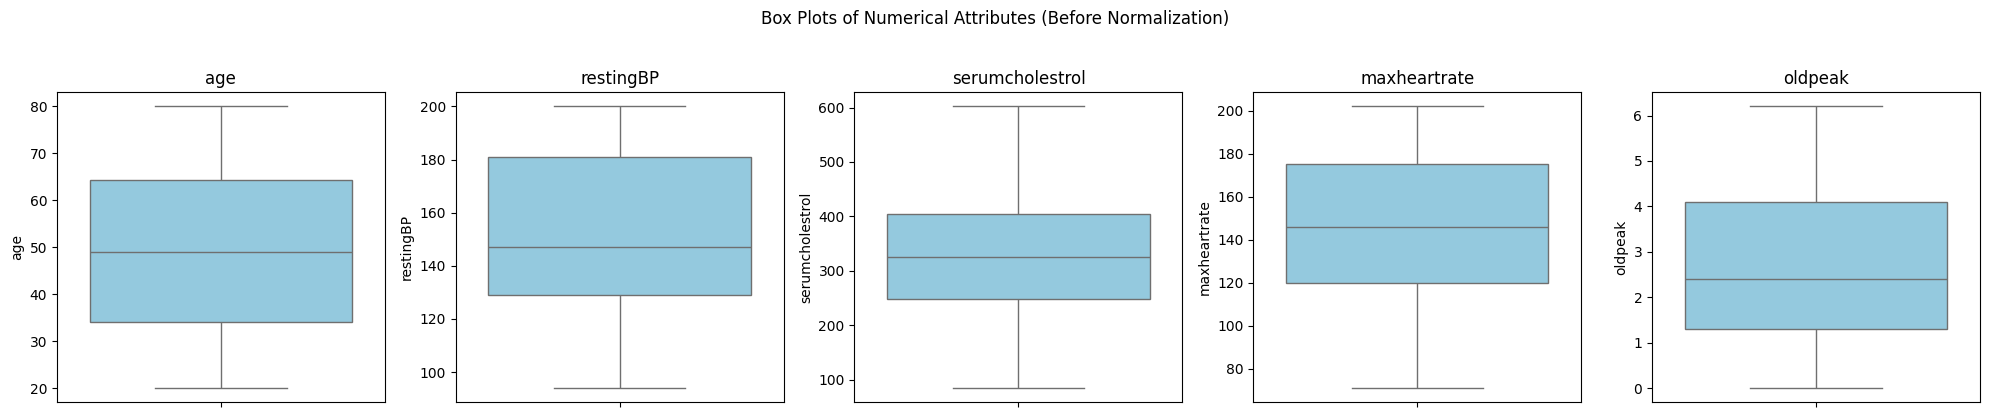

In [9]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4*len(numerical_cols), 4))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
fig.suptitle("Box Plots of Numerical Attributes (Before Normalization)", y=1.03)
plt.tight_layout()
plt.show()


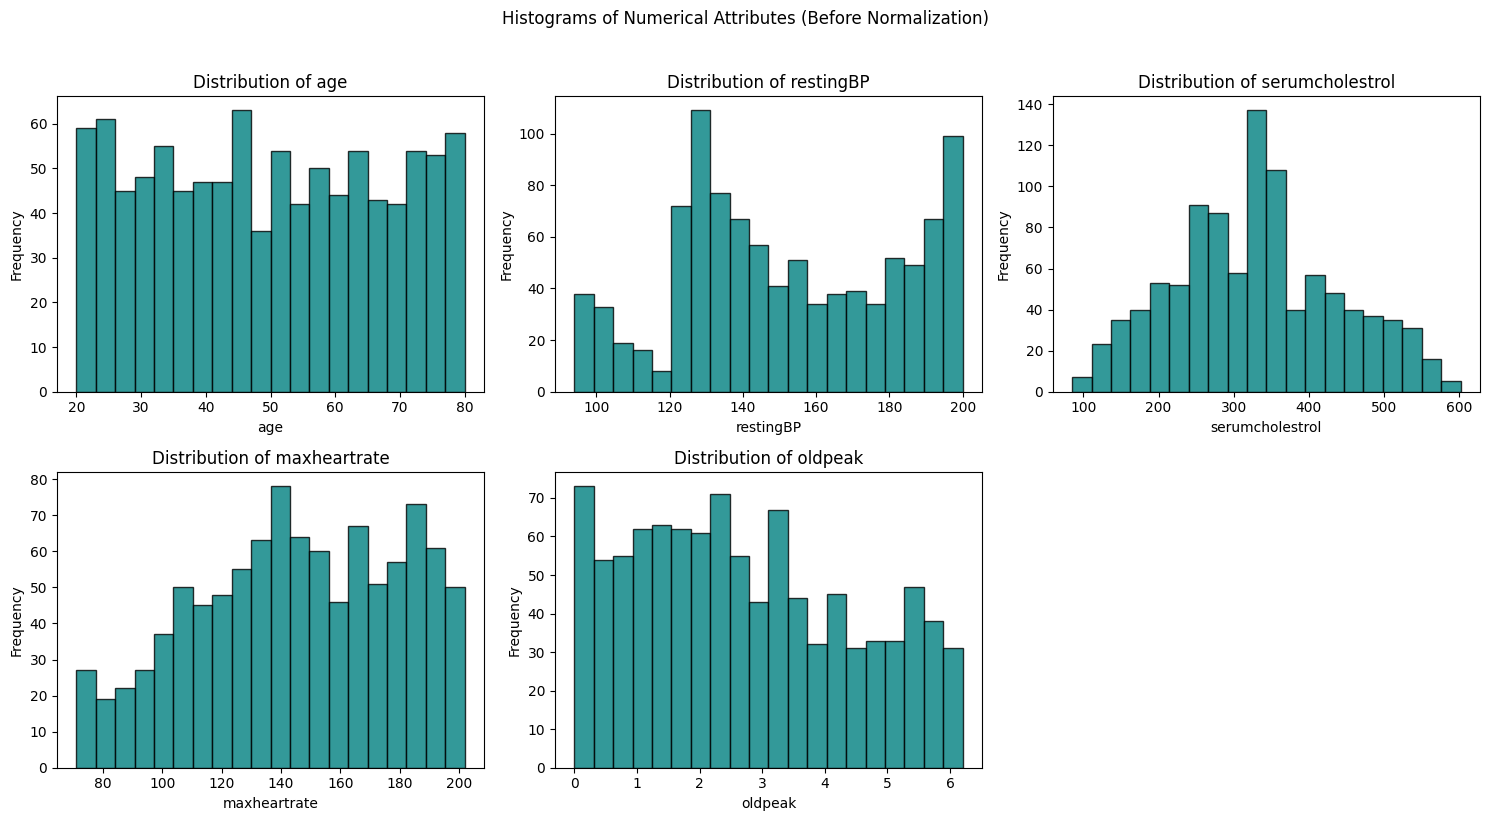

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numerical_cols):
    ax.hist(df[col], bins=20, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
axes[-1].axis('off')
fig.suptitle("Histograms of Numerical Attributes (Before Normalization)", y=1.02)
plt.tight_layout()
plt.show()


**Observation:** the attributes sit on very different numeric ranges (`oldpeak` is a small decimal, `serumcholestrol` runs into the hundreds), which is the visual confirmation of the scale mismatch discussed in Part A.


## Part C: Normalization Techniques

### 1. Min-Max Normalization
Scales every value of a feature into the range **[0, 1]** using:

`x' = (x - min(x)) / (max(x) - min(x))`


In [12]:
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df[numerical_cols])

comparison_minmax = pd.DataFrame({
    f'{col}_original': df[col].values for col in numerical_cols
})
for col in numerical_cols:
    comparison_minmax[f'{col}_minmax'] = df_minmax[col].values

comparison_minmax.head(10)


,age_original,restingBP_original,serumcholestrol_original,maxheartrate_original,oldpeak_original,age_minmax,restingBP_minmax,serumcholestrol_minmax,maxheartrate_minmax,oldpeak_minmax
0,53,171,326.0,147,5.3,0.550000,0.726415,0.466151,0.580153,0.854839
1,40,94,229.0,115,3.7,0.333333,0.000000,0.278530,0.335878,0.596774
2,49,133,142.0,202,5.0,0.483333,0.367925,0.110251,1.000000,0.806452
3,43,138,295.0,153,3.2,0.383333,0.415094,0.406190,0.625954,0.516129
4,31,199,326.0,136,5.3,0.183333,0.990566,0.466151,0.496183,0.854839
5,24,173,326.0,161,4.7,0.066667,0.745283,0.466151,0.687023,0.758065
6,79,130,240.0,157,2.5,0.983333,0.339623,0.299807,0.656489,0.403226
7,52,127,345.0,192,4.9,0.533333,0.311321,0.502901,0.923664,0.790323
8,62,121,357.0,138,2.8,0.700000,0.254717,0.526112,0.511450,0.451613
9,61,190,181.0,150,2.9,0.683333,0.905660,0.185687,0.603053,0.467742


In [13]:
df_minmax[numerical_cols].describe()


,age,restingBP,serumcholestrol,maxheartrate,oldpeak
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.487367,0.544783,0.471422,0.568527,0.436726
std,0.297746,0.282691,0.212833,0.260994,0.277541
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.233333,0.330189,0.317215,0.372137,0.209677
50%,0.483333,0.500000,0.466151,0.572519,0.387097
75%,0.737500,0.820755,0.617505,0.793893,0.661290
max,1.000000,1.000000,1.000000,1.000000,1.000000


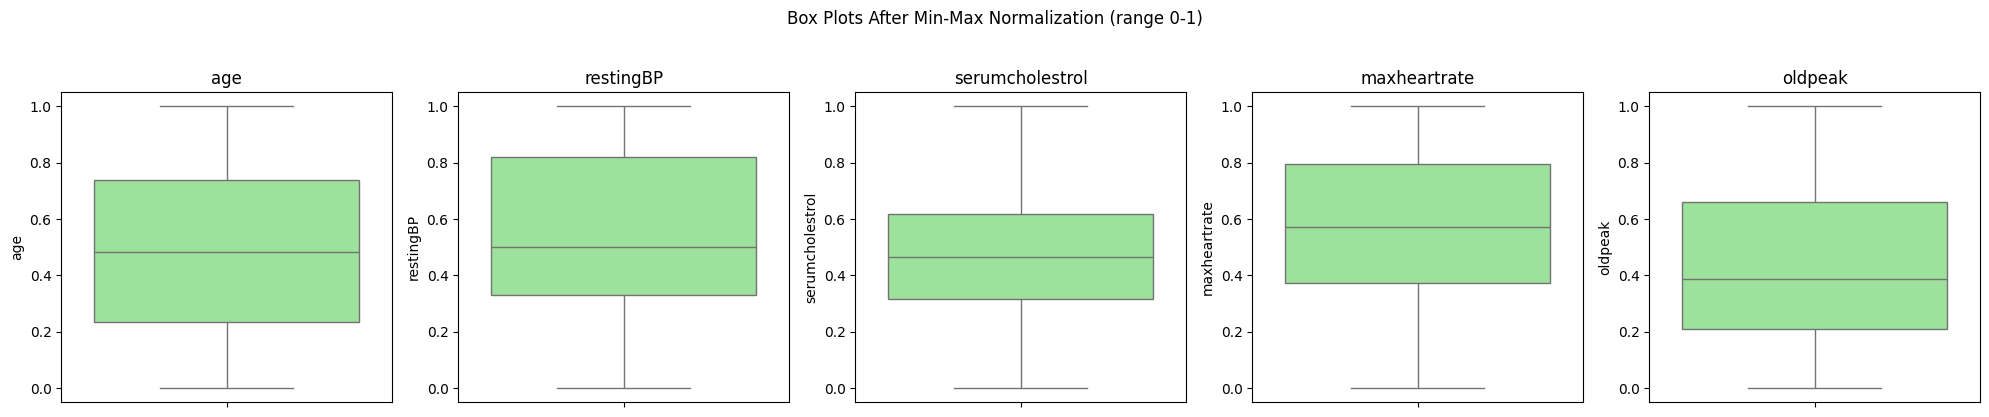

In [14]:
fig, axes = plt.subplots(1, len(numerical_cols), figsize=(4*len(numerical_cols), 4))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df_minmax[col], ax=ax, color='lightgreen')
    ax.set_title(col)
    ax.set_ylim(-0.05, 1.05)
fig.suptitle("Box Plots After Min-Max Normalization (range 0-1)", y=1.03)
plt.tight_layout()
plt.show()


**Analysis:** every numerical attribute is now bounded between 0 and 1 (see the `describe()` output: min = 0, max = 1 for all columns). The *shape* of each distribution is preserved — Min-Max scaling is a linear transformation — but it is sensitive to outliers, since a single extreme value stretches/compresses the rest of the data within the fixed [0, 1] range.


### 2. Z-Score Normalization (Standardization)
Transforms each feature to have **mean = 0** and **standard deviation = 1** using:

`x' = (x - mean(x)) / std(x)`



In [15]:
zscore_scaler = StandardScaler()
df_zscore = df.copy()
df_zscore[numerical_cols] = zscore_scaler.fit_transform(df[numerical_cols])

comparison_zscore = pd.DataFrame({
    f'{col}_original': df[col].values for col in numerical_cols
})
for col in numerical_cols:
    comparison_zscore[f'{col}_zscore'] = df_zscore[col].values

comparison_zscore.head(10)


,age_original,restingBP_original,serumcholestrol_original,maxheartrate_original,oldpeak_original,age_zscore,restingBP_zscore,serumcholestrol_zscore,maxheartrate_zscore,oldpeak_zscore
0,53,171,326.0,147,5.3,0.210464,0.642833,-0.024777,0.044567,1.507245
1,40,94,229.0,115,3.7,-0.517591,-1.928098,-0.906757,-0.891840,0.576955
2,49,133,142.0,202,5.0,-0.013553,-0.625938,-1.697812,1.654017,1.332816
3,43,138,295.0,153,3.2,-0.349578,-0.458995,-0.306647,0.220143,0.286239
4,31,199,326.0,136,5.3,-1.021629,1.577717,-0.024777,-0.277323,1.507245
5,24,173,326.0,161,4.7,-1.413659,0.709610,-0.024777,0.454245,1.158386
6,79,130,240.0,157,2.5,1.666574,-0.726104,-0.806739,0.337194,-0.120763
7,52,127,345.0,192,4.9,0.154460,-0.826270,0.147982,1.361390,1.274673
8,62,121,357.0,138,2.8,0.714502,-1.026603,0.257093,-0.218797,0.053666
9,61,190,181.0,150,2.9,0.658498,1.277218,-1.343201,0.132355,0.111809


In [16]:
summary = df_zscore[numerical_cols].agg(['mean', 'std']).T
summary.columns = ['mean_after_zscore', 'std_after_zscore']
summary


,mean_after_zscore,std_after_zscore
age,1.421085e-16,1.0005
restingBP,-4.760636e-16,1.0005
serumcholestrol,-2.060574e-16,1.0005
maxheartrate,-1.119105e-16,1.0005
oldpeak,9.769963e-18,1.0005


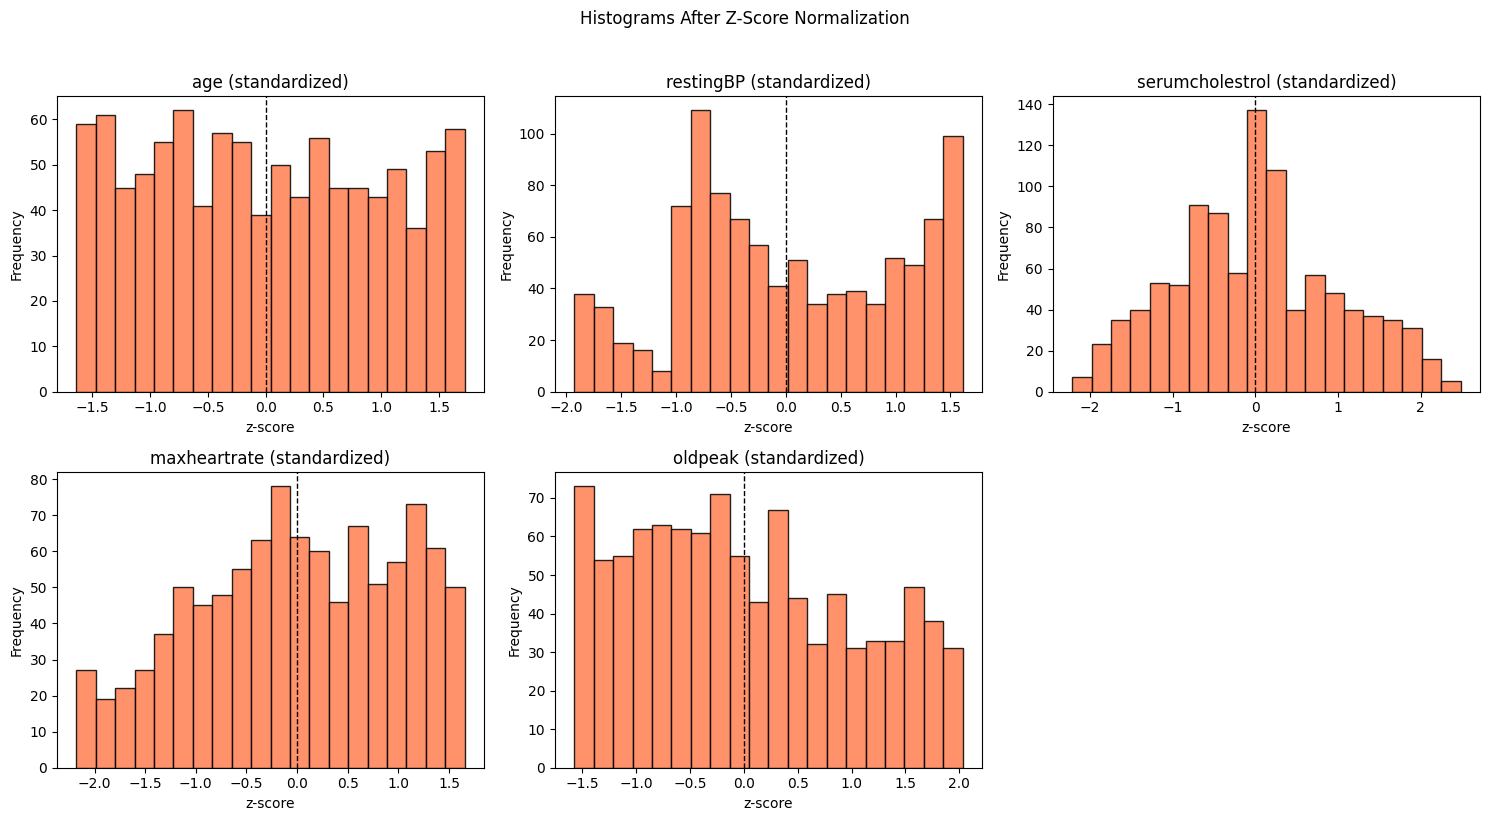

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, col in zip(axes, numerical_cols):
    ax.hist(df_zscore[col], bins=20, color='coral', edgecolor='black', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{col} (standardized)')
    ax.set_xlabel('z-score')
    ax.set_ylabel('Frequency')
axes[-1].axis('off')
fig.suptitle("Histograms After Z-Score Normalization", y=1.02)
plt.tight_layout()
plt.show()


**Analysis:** the `mean`/`std` table above confirms every standardized column now has mean ≈ 0 and standard deviation ≈ 1. Unlike Min-Max scaling, standardized values are **not bounded** to a fixed interval — they can be negative, and extreme values simply appear as large positive/negative z-scores rather than being compressed, which makes Z-score normalization more robust to outliers than Min-Max scaling.



### Most suitable technique for this healthcare dataset

**Z-score normalization is the more suitable choice for this cardiovascular dataset**, for these reasons:

1. Clinical attributes such as `serumcholestrol`, `restingBP`, and `maxheartrate` contain genuine outlier patients (very high cholesterol, unusually low/high heart rate) that are clinically meaningful, not noise. Min-Max scaling would compress the bulk of "normal" patients into a tiny sub-range to accommodate these few extreme values, reducing the model's ability to discriminate among them.
2. Standardization centers each feature at 0, which works well with the regression- and distance-based models (logistic regression, SVM, PCA) commonly used for disease-risk prediction tasks on tabular clinical data.
3. New patient records collected after training may have values slightly outside the original training min/max (e.g., a higher cholesterol reading); Z-score normalization handles this gracefully, whereas Min-Max would push such values outside [0, 1].

Min-Max normalization would still be preferable only if the downstream model specifically required bounded inputs (e.g., certain neural-network activation functions), but for general statistical and ML modelling of this dataset, **Z-score standardization is recommended**.
